MODULE 2 (LAB 1) Practice+Solutions

Data Visualisations in Python are actually done with MATPLOTLIB

Matplotlib:
It is a robust 2D plotting library that provides a high degree of control over every aspect of a figure. It's like having a full box of crayons, where you can draw and customize anything you want.
Seaborn:
This is a higher-Level library that simplifies the creation of common informative and statistical plots.

Key components to focus on-


1.   Figure: the overall window,which everything is drawn
2.  Axes:The part of this figure which actually contains the actuall plots
3.X axis,Y axis,X labled axis,Y label axis
4.Major ticks or Minor Ticks( these actually provide the additional scale sub divisions)
5Markers(Scatter Plot)
Individual Points representing the plot to make it easier
### 6.Spines:
The borders of the plot area (top, bottom, left, right), which can be customized or hidden.


We will learn it based on the data,we will import the necessary files or the libraries

In [4]:
import requests
url="https://raw.githubusercontent.com/SP9144/FMML_Data/main/Automobile_data.csv"
response=requests.get(url);

In [2]:
import numpy as np
import pandas as pd
import seaborn  as sns
from io import StringIO
import matplotlib.pyplot as plt


In [5]:
data=StringIO(response.text)
data = pd.read_csv(data)
print("Number of data points =", len(data))
data.head()


Number of data points = 205


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [6]:
data.replace("?", np.nan, inplace = True)#Replacig the ?
data = data.dropna()# dropping the ?
print(len(data))# putting the len of the data

159


In [7]:

X = data.drop("price", axis = 1)
y = pd.to_numeric(data["price"])

Features (X): The input variables we use to make a prediction (e.g., horsepower, make, body-style).
Target (y): The variable we are trying to predict (in this case, price).

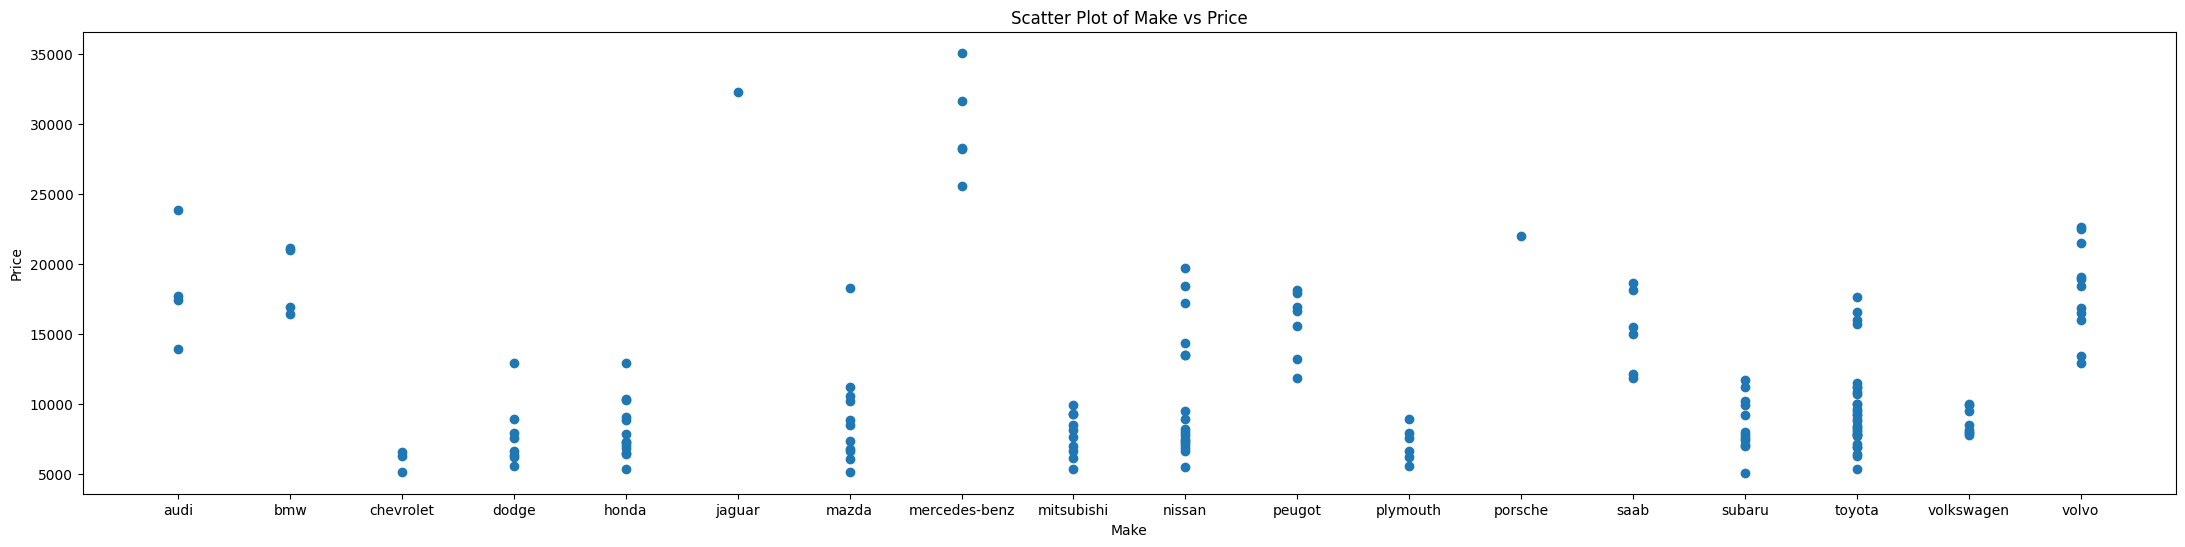

In [9]:
plt.figure(figsize=(27, 6))
plt.scatter(X["make"],y)
plt.xlabel("Make")
plt.ylabel("Price")
plt.title("Scatter Plot of Make vs Price")
plt.show()

USING SEABORN

/tmp/ipykernel_10481/174416021.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=X["make"],y=y, palette="Set3").set_title('Car Manufacturer vs Price - Box Plot')


Text(0.5, 1.0, 'Car Manufacturer vs Price - Box Plot')

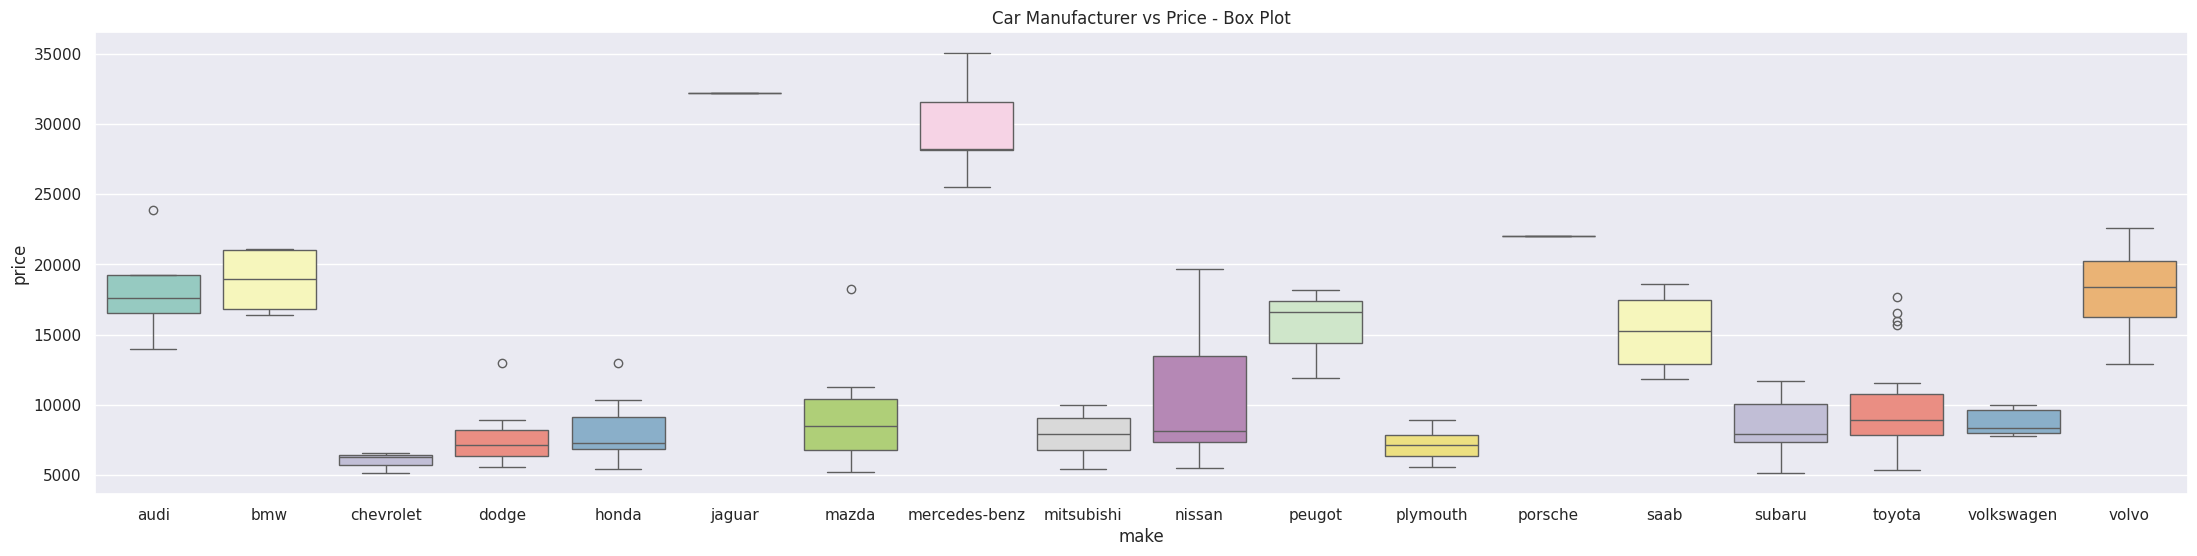

In [10]:
sns.set(rc={'figure.figsize':(27,6)})
sns.boxplot(x=X["make"],y=y, palette="Set3").set_title('Car Manufacturer vs Price - Box Plot')

The Violin Plot: Box Plot + Density

A Violin Plot is a powerful hybrid. It combines a box plot (visible in the center) with a Kernel Density Estimate (KDE) on each side. The KDE shows the distribution of the data—wider sections mean more data points are concentrated there, while narrower sections mean fewer.We can also use the Violin Plot to understand the distribution within each car maker in a better way.

/tmp/ipykernel_10481/426109079.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=X["make"],y=y, palette="Set3").set_title('Car maker vs Price - Violin Plot')


Text(0.5, 1.0, 'Car maker vs Price - Violin Plot')

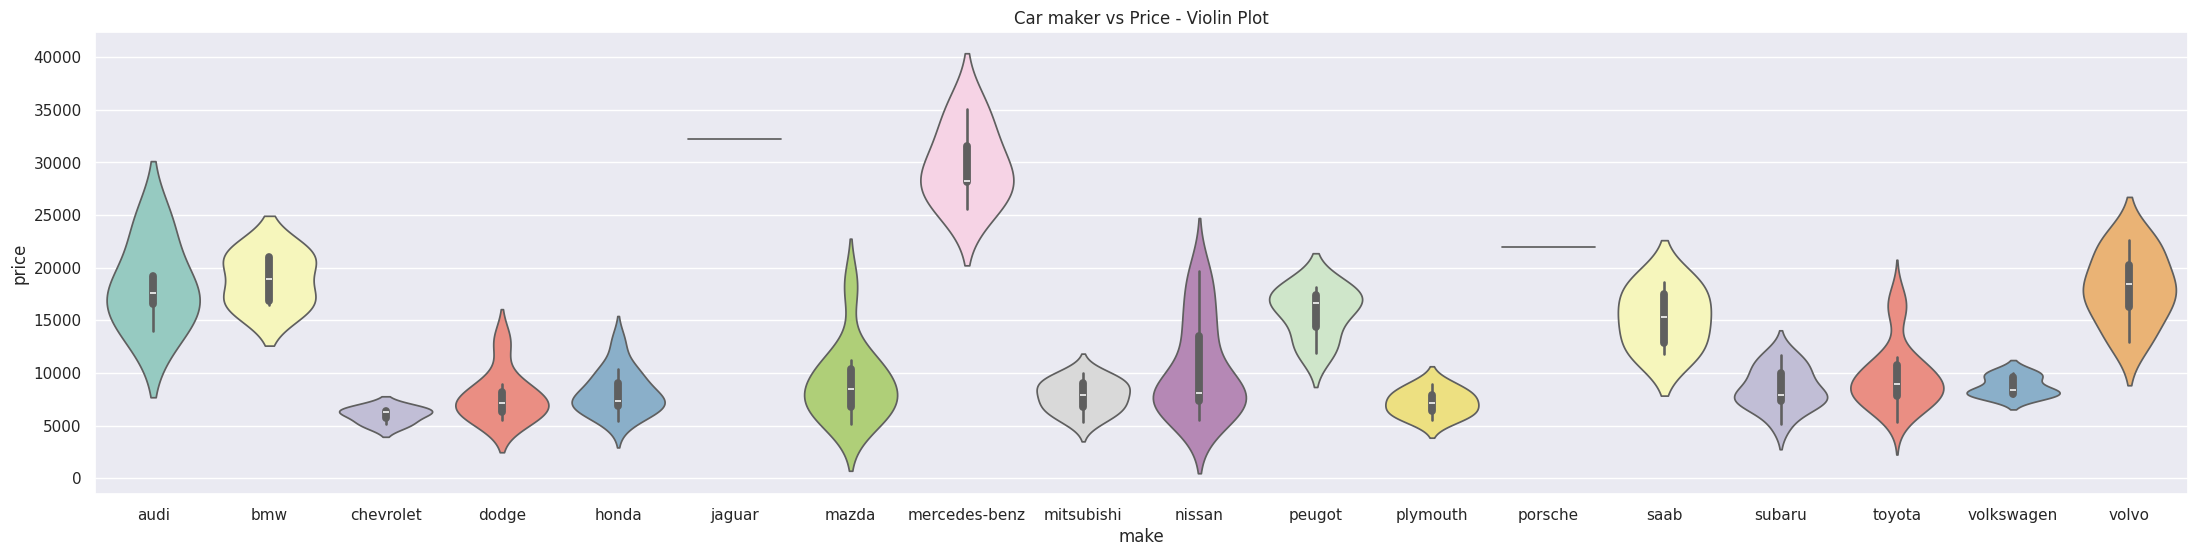

In [11]:
sns.violinplot(x=X["make"],y=y, palette="Set3").set_title('Car maker vs Price - Violin Plot')

HORSE POWER PLOT

/tmp/ipykernel_10481/541565243.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=X["make"],y=pd.to_numeric(X["horsepower"]), palette="Set3").set_title('Car maker vs Horsepower Box Plot')


Text(0.5, 1.0, 'Car maker vs Horsepower Box Plot')

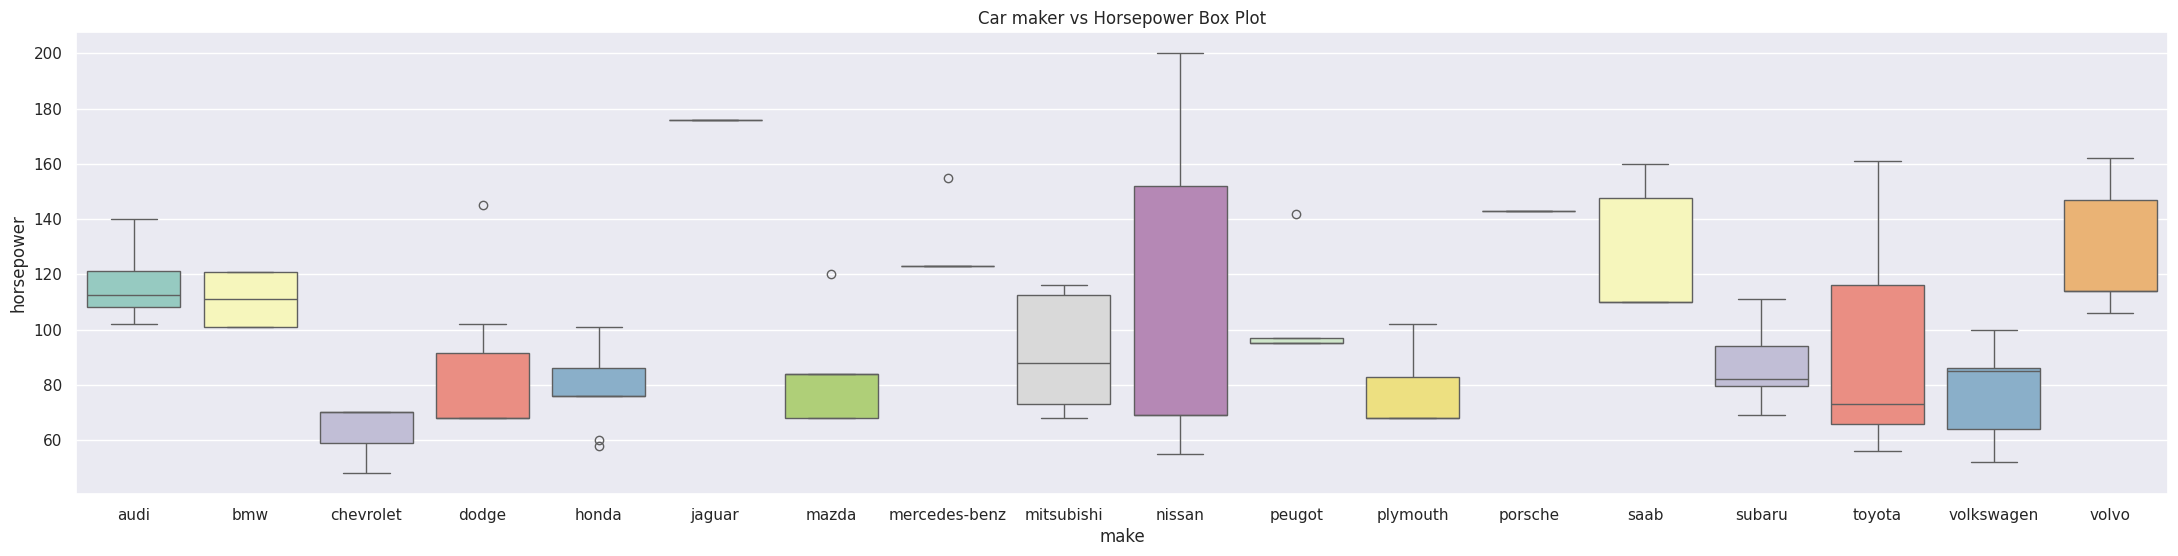

In [13]:
sns.boxplot(x=X["make"],y=pd.to_numeric(X["horsepower"]), palette="Set3").set_title('Car maker vs Horsepower Box Plot')

<Axes: xlabel='horsepower', ylabel='price'>

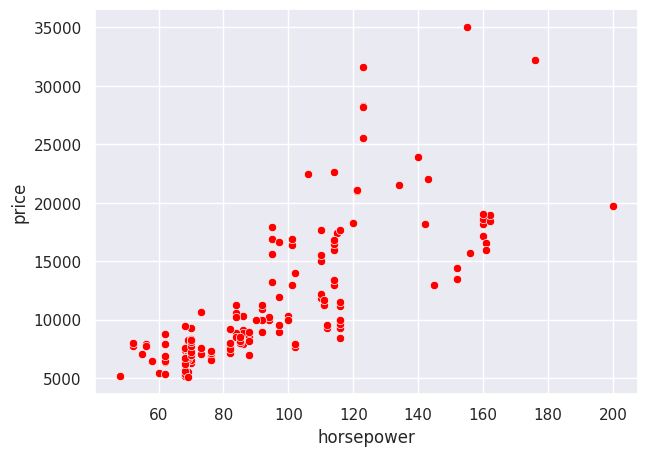

In [14]:
sns.set(rc={'figure.figsize':(7,5)})
sns.scatterplot(x=pd.to_numeric(X["horsepower"]), y = y, color = "red")

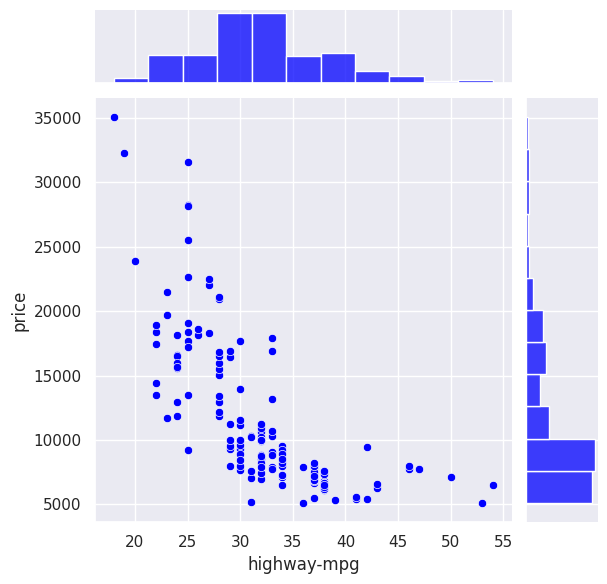

In [20]:
X["highway-mpg"] = pd.to_numeric(X["highway-mpg"])
sns.jointplot(x=X["highway-mpg"], y=y, kind="scatter", color="blue")

plt.show()


The analysis shows that fuel efficiency (highway-mpg) has a negative impact on car price. Most cars fall in the mid-range category, with a few outliers representing luxury and economy extremes.

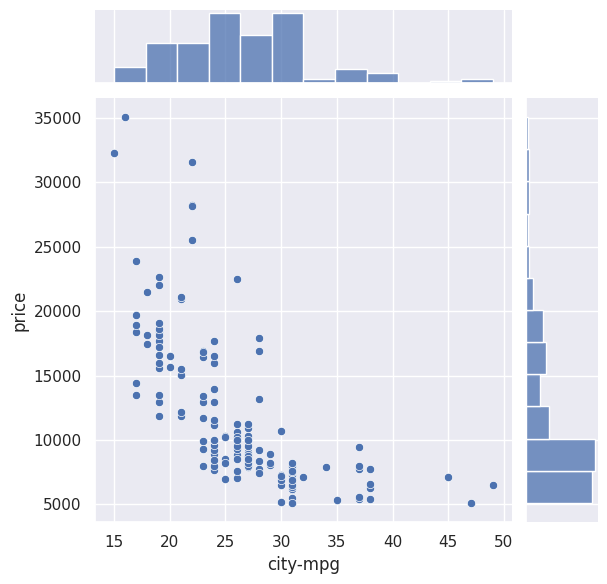

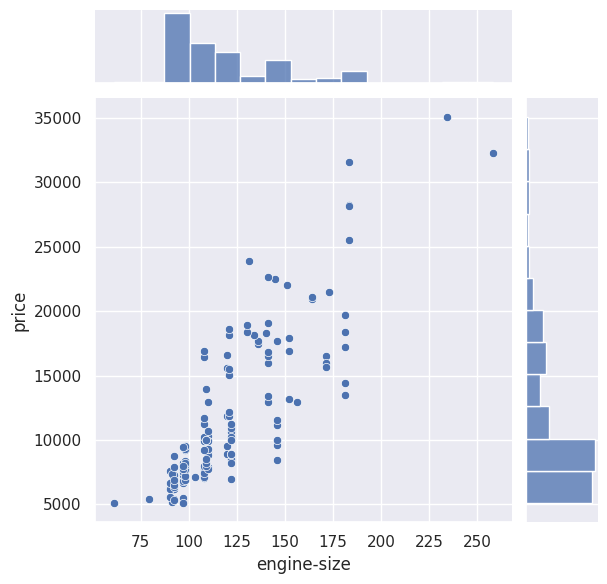

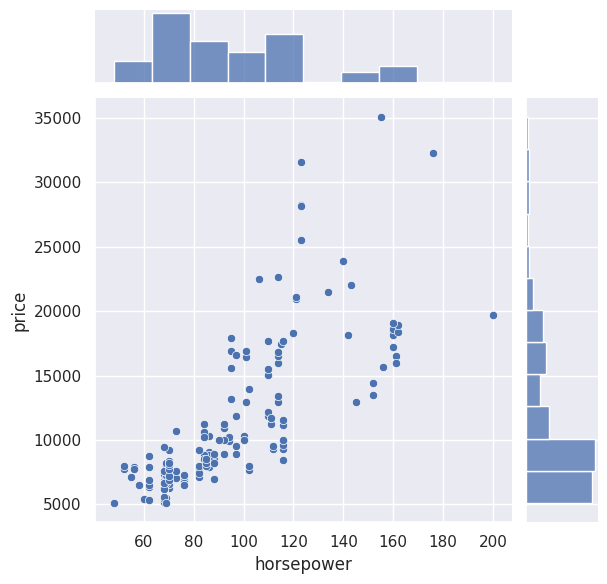

In [21]:
features = ["city-mpg", "engine-size", "horsepower"]

for feature in features:
    sns.jointplot(x=pd.to_numeric(X[feature]), y=y, kind="scatter")
    plt.show()

The jointplot shows a moderate to strong negative correlation between city-mpg and price. Most cars lie in the mid-range mpg and price category. High-priced cars generally have low fuel efficiency, while highly fuel-efficient cars are mostly low-priced. A few outliers represent luxury and economy extremes.


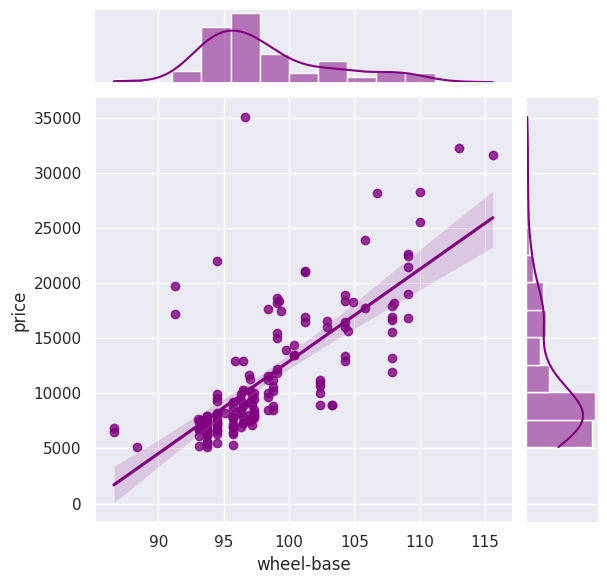

In [24]:
############################
### CHANGE THE CODE HERE ###

feature = "wheel-base"

############################


sns.jointplot(x=pd.to_numeric(X[feature]), y = y, kind="reg", color = 'purple')

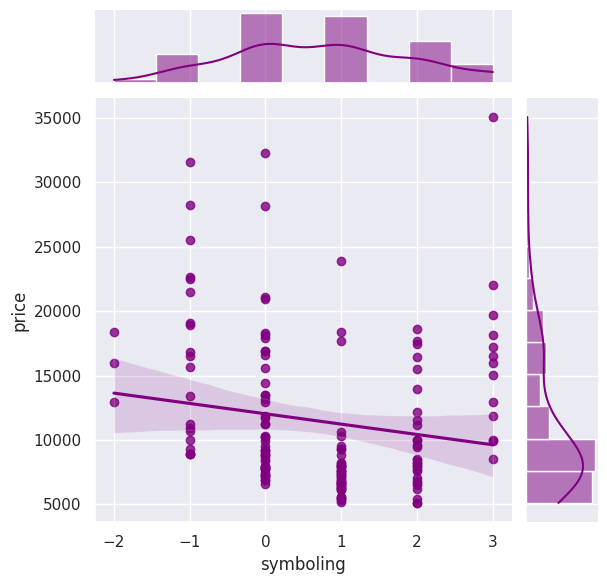

In [25]:
############################
### CHANGE THE CODE HERE ###

feature = "symboling"

############################


sns.jointplot(x=pd.to_numeric(X[feature]), y = y, kind="reg", color = 'purple')

Question 1: Which body-type has the highest median price? Which one appears to be the costliest overall?

Answer:
The body-type with the highest median price is convertible. It appears to be the costliest overall because its median value is highest among all categories, and its price range (including the upper whisker) is also significantly higher than the others. Most of the data points for convertibles lie in a higher price range compared to other body styles.

Question 2: Is looking only at the maximum value (top whisker or outlier) a good way to determine the costliest body-style? Why is the interquartile range (IQR) a better indicator?

Answer:
No, relying only on the maximum value is not a good way to determine the costliest body-style because the maximum value may represent an outlier or an unusual case rather than the general trend.

The interquartile range (IQR), represented by the box in the box plot, is a better indicator because it shows the range of the middle 50% of the data. It provides a more reliable understanding of the typical price distribution and is not heavily affected by extreme values. Therefore, it reflects the general pricing pattern more accurately than the maximum value.

Question 3: Do you think the body-style of a car could be a good predictor for its price? Why or why not?

Answer:
Yes, body-style can be considered a useful predictor of a car’s price because different body styles show distinct price distributions. For example, convertibles tend to have higher prices, while hatchbacks generally have lower prices, and sedans and wagons fall in the mid-range.

However, body-style alone is not sufficient to accurately predict price. Other factors such as engine size, horsepower, brand, and additional features also significantly influence the price. Therefore, body-style should be used along with other variables for better prediction accuracy.

/tmp/ipykernel_10481/1970078701.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x=X["body-style"], y=y, palette="Set2")
/tmp/ipykernel_10481/1970078701.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(ax=axes[1], x=X["body-style"], y=y, palette="Set3")


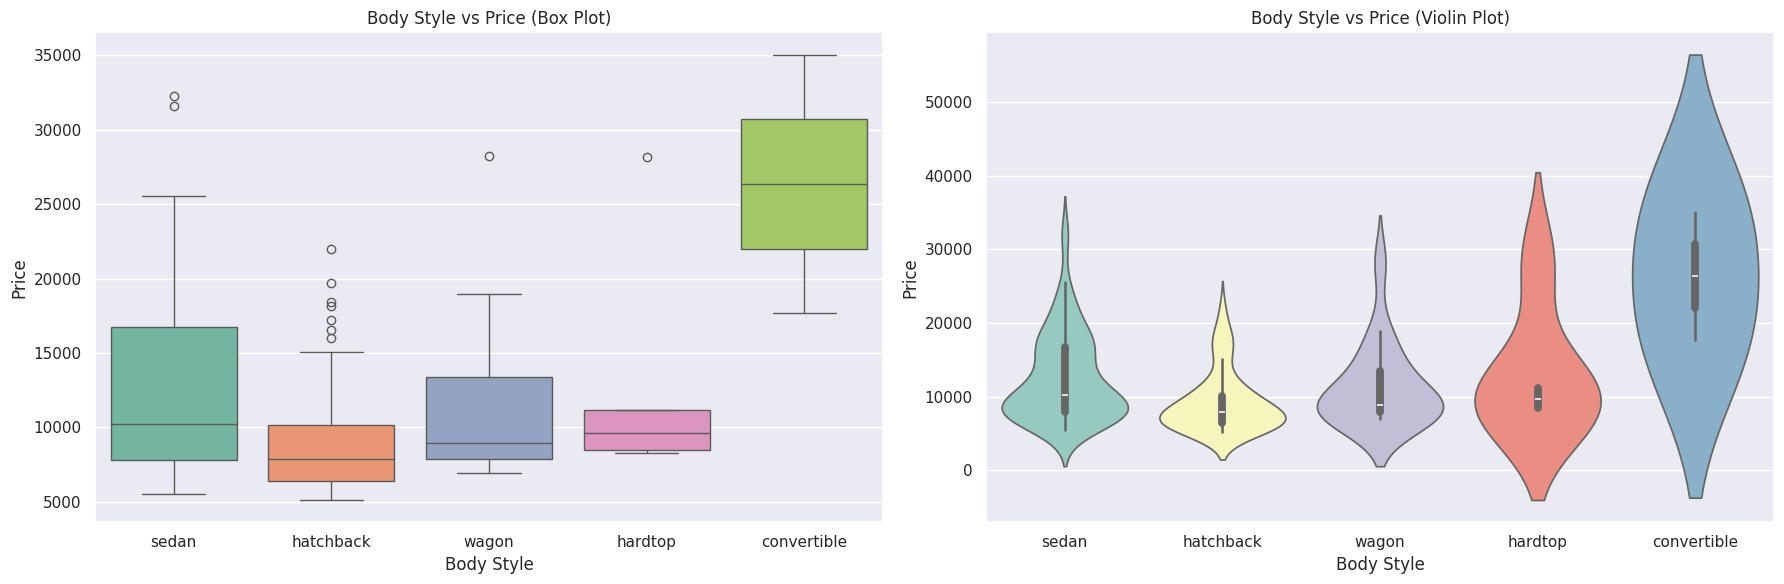

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, axes = plt.subplots(1, 2, figsize=(18, 6))


sns.boxplot(ax=axes[0], x=X["body-style"], y=y, palette="Set2")
axes[0].set_title("Body Style vs Price (Box Plot)")
axes[0].set_xlabel("Body Style")
axes[0].set_ylabel("Price")


sns.violinplot(ax=axes[1], x=X["body-style"], y=y, palette="Set3")
axes[1].set_title("Body Style vs Price (Violin Plot)")
axes[1].set_xlabel("Body Style")
axes[1].set_ylabel("Price")


plt.tight_layout()


plt.show()

Using multiple plots side-by-side helps in better comparison. The box plot provides a summary of the data distribution, while the violin plot gives additional insight into the density and spread of the data for each body style.